In [15]:
!pip install bangla-stemmer


  Using cached bangla_stemmer-1.0-py3-none-any.whl.metadata (2.4 kB)
Using cached bangla_stemmer-1.0-py3-none-any.whl (9.1 kB)



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [24]:
!pip install imbalanced-learn

  Using cached imbalanced_learn-0.14.0-py3-none-any.whl.metadata (8.8 kB)
Using cached imbalanced_learn-0.14.0-py3-none-any.whl (239 kB)



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import numpy as np
import pandas as pd
newdata = pd.read_csv("../data/final_bn_data.csv")
newdata.head()

,category,headline,content,label
0,National,৮ দিনে ১৮ বিল পাস!,দশম জাতীয় সংসদের মেয়াদ শেষ হয়ে যাচ্ছে। কার্যত ...,0.0
1,Sports,আ’লীগের জনসভায় লোকে লোকারণ্য ফেনী ট্রাংক রোড,একাদশ জাতীয় সংসদ নির্বাচনকে সামনে রেখে সাংগঠনি...,0.0
2,National,মাদ্রাসায় জোড়া খুন: পরিচালক তিন দিনের রিমান্ডে,গাজীপুরে জোড়া খুন মামলার প্রধান আসামি মাদ্রাসা...,0.0
3,Sports,নেপালকে হারিয়ে গ্রুপ চ্যাম্পিয়ন বাংলাদেশ,সাফ অনূর্ধ্ব-১৮ নারী ফুটবল চ্যাম্পিয়নশিপে নেপা...,1.0
4,National,কুড়িগ্রামে ২ শিক্ষার্থীর লাশ উদ্ধার,কুড়িগ্রাম প্রতিনিধি : কুড়িগ্রাম সদর উপজেলার বে...,1.0


In [5]:
newdata= newdata.drop(['headline', 'category'], axis=1)
newdata.to_csv('newDataset.csv', index=False)


In [ ]:
# Install required package
!pip install bangla-stemmer  # CHANGED: kept same

import pandas as pd
import re
import string
from bangla_stemmer.stemmer import stemmer

# Bangla stopwords list (keep your full list)
bangla_stopwords = set([  
    'অবশ্য','অনেক','অনেকে','অনেকেই','অন্তত','অন্য','আজ','আছে','আপনার','আপনি',
'আবার','আমরা','আমাকে','আমাদের','আমার','আমি','আরও','আর','আগে','আগেই','আই',
'অতএব','আগামী','অবধি','অনুযায়ী','আদ্যভাগে','এই','একই','একে','একটি','এখন',
'এখনও','এখানে','এখানেই','এটি','এটা','এটাই','এতটাই','এবং','একবার','এবার',
'এদের','এঁদের','এমন','এমনকী','এল','এর','এরা','এঁরা','এস','এতে','এসে','এ',
'ঐ','ই','ইহা','ইত্যাদি','উনি','উপর','উপরে','উচিত','ও','ওই','ওর','ওরা','ওঁর',
'ওঁরা','ওকে','ওদের','ওঁদের','ওখানে','কত','কবে','করতে','কয়েক','কয়েকটি','করবে',
'করলেন','করার','কারও','করা','করি','করিয়ে','করাই','করলে','করিতে','করিয়া','করেছিলেন',
'করছে','করছেন','করেছেন','করেছে','করেন','করবেন','করায়','করে','করেই','কাছ','কাছে',
'কাজে','কারণ','কিছু','কিছুই','কিন্তু','কিংবা','কি','কী','কেউ','কেউই','কাউকে','কেন',
'কে','কোনও','কোনো','কোন','কখনও','ক্ষেত্রে','খুব','গুলি','গিয়ে','গিয়েছে','গেছে',
'গেল','গেলে','গোটা','চলে','ছাড়া','ছাড়াও','ছিলেন','ছিল','জন্য','জানা','ঠিক','তিনি',
'তিনঐ','তিনিও','তখন','তবে','তবু','তাঁদের','তাঁরা','তাঁর','তাঁকে','তাই','তেমন','তাকে',
'তাহা','তাহাতে','তাহার','তাদের','তারপর','তারা','তার','তাহলে','তা','তাও','তাতে','তো',
'তত','তুমি','তোমার','তথা','থাকে','থাকা','থাকায়','থেকে','থেকেও','থাকবে','থাকেন',
'থাকবেন','থেকেই','দিকে','দিতে','দিয়ে','দিয়েছে','দিয়েছেন','দিলেন','দু','দুটি','দুটো',
'দেয়','দেওয়া','দেওয়ার','দেখা','দেখে','দেখতে','দ্বারা','ধরে','ধরা','নয়','নানা','না',
'নাকি','নাগাদ','নিতে','নিজে','নিজেই','নিজের','নিজেদের','নিয়ে','নেওয়া','নেওয়ার','নেই',
'নাই','পক্ষে','পর্যন্ত','পাওয়া','পারেন','পারি','পারে','পরে','পরেই','পরেও','পর','পেয়ে',
'প্রতি','প্রভৃতি','প্রায়','ফের','ফলে','ব্যবহার','বলতে','বললেন','বলেছেন','বলল','বলা',
'বলেন','বলে','বহু','বসে','বার','বা','বিনা','বরং','বদলে','বাদে','বিশেষ','বিভিন্ন',
'বিষয়টি','ব্যাপারে','ভাবে','ভাবেই','মধ্যে','মধ্যেই','মধ্যেও','মধ্যভাগে','মাধ্যমে','মাত্র',
'মতো','মতোই','মোটেই','যখন','যদি','যদিও','যাবে','যায়','যাকে','যাওয়া','যাওয়ার','যত',
'যতটা','যা','যার','যারা','যাঁর','যাঁরা','যাদের','যান','যাচ্ছে','যেতে','যাতে','যেন','যেমন',
'যেখানে','যিনি','যে','রেখে','রাখা','রয়েছে','রকম','শুধু','সঙ্গে','সঙ্গেও','সমস্ত','সব',
'সবার','সহ','সুতরাং','সহিত','সেই','সেটা','সেটি','সেটাই','সেটাও','সম্প্রতি','সেখান',
'সেখানে','সে','স্পষ্ট','স্বয়ং','হইতে','হইবে','হৈলে','হইয়া','হচ্ছে','হত','হতে','হতেই',
'হবে','হবেন','হয়েছিল','হয়েছে','হয়েছেন','হয়ে','হয়নি','হয়','হয়েই','হয়তো','হল','হলে',
'হলেই','হলেও','হলো','হিসাবে','হওয়া','হওয়ার','হওয়ায়','হন','হোক','জন','জনকে','জনের',
'জানতে','জানায়','জানিয়ে','জানানো','জানিয়েছে','জন্য','জন্যওজে','জে','বেশ','দেন','তুলে',
'ছিলেন','চান','চায়','চেয়ে','মোট','যথেষ্ট','টি','অনুযায়ী','উত্তর','কমনে','প্রথম','প্রযন্ত',
'প্রাথমিক','মনে','নতুন','পি','পেয়্র্','বক্তব্য','ধামার','সি','সাধারণ','সামনে','হাজার'
])

# Simple stemmer for common suffixes 
def simple_bangla_stem(word):
    suffixes = ["গুলো", "দের", "মতো", "গুলোই", "টিতে", "টার", "রা", "টি", "টা", "তে", "র", "এর", "ই", "ও"]
    for suf in sorted(suffixes, key=len, reverse=True):
        if word.endswith(suf) and len(word) > len(suf) + 1:
            return word[:-len(suf)]
    return word


bangla_normalization_dict = {
    "মুরগি": "মুরগি",
    "মুরগী": "মুরগি",
    "মুরগীটা": "মুরগি",
    "মুরগিটা": "মুরগি",
    "মুরগিগুলো": "মুরগি",
    "শিয়াল": "শিয়াল",
    "শেয়াল": "শিয়াল",
    "শিয়ালটা": "শিয়াল",
    "শিয়ালগুলো": "শিয়াল",
    "শিয়াল": "শিয়াল",
    "মানুষ": "মানুষ",
    "মাঞ্জুষ": "মানুষ",
    "মানুষটা": "মানুষ",
    "মানুষগুলো": "মানুষ",
    "ইন্টারভিউ": "ইন্টারভিউ",
    "ক্যামেরাম্যান": "ক্যামেরাম্যান",
    "মডেল": "মডেল",
    "টিম": "টিম",
    "বস": "বস",
    "ভিডি": "ভিডিও",
    "ভিডিও": "ভিডিও",
    "ফরান্স": "ফ্রান্স",
    "ফ্রান্স": "ফ্রান্স",
    "খাচ্ছে": "খাওয়া",
    "খাচ্ছেন": "খাওয়া",
    "খায়": "খাওয়া",
    "খেতে": "খাওয়া",
    "খেয়েছে": "খাওয়া",
    "দেয়": "দেওয়া",
    "দিচ্ছে": "দেওয়া",
    "দিয়েছে": "দেওয়া",
    "একটি": "এক",
    "এক": "এক",
    "দুইটি": "দুই",
    "দুই": "দুই",
    "তিনটি": "তিন",
    "তিন": "তিন",
    "চারটি": "চার",
    "চার": "চার",
    "পাঁচটি": "পাঁচ",
    "পাঁচ": "পাঁচ",
    "ছেলে": "ছেলে",
    "মেয়ে": "মেয়ে",
    "মেয়ে": "মেয়ে",
    "বাবা": "বাবা",
    "মা": "মা",
    "ছেলেটি": "ছেলে",
    "মেয়েটি": "মেয়ে",
    "বইটি": "বই",
    "বই": "বই",
    "ঘরটা": "ঘর",
    "ঘর": "ঘর",
    "স্কুল": "স্কুল",
    "বিদ্যালয়": "বিদ্যালয়",
}


# Suppress print outputs from stemmer
import sys, io
def suppress_stdout(func, *args, **kwargs):
    old_stdout = sys.stdout
    sys.stdout = io.StringIO()
    try:
        result = func(*args, **kwargs)
    finally:
        sys.stdout = old_stdout
    return result

# Main preprocessing function
def preprocessNew_bangla_text(text):
    text = str(text)

    # Remove HTML, URLs, emails, hashtags, Latin letters, and numbers
    text = re.sub(r"<.*?>|http\S+|www\S+|\S*@\S*|\#\S*", " ", text)  # CHANGED: combined into one regex
    text = re.sub(r"[a-zA-Z০-৯0-9]+", " ", text)  # CHANGED: removed unnecessary parts

    # Remove punctuation
    punct_pattern = f"[{string.punctuation}।॥‘’“”—৳]"  # CHANGED: unified punctuation
    text = re.sub(punct_pattern, " ", text)

    # Normalize certain characters
    text = re.sub("[য়য়]", "য়", text)
    text = re.sub("[ঋৃ]", "ঋ", text)
    text = re.sub("[ঁ্]", "", text)
    text = re.sub(r"\s+", " ", text).strip()  # CHANGED: condensed whitespace cleanup

    # Remove consecutive repeated words
    words = text.split()
    words = [words[i] for i in range(len(words)) if i == 0 or words[i] != words[i-1]]  # CHANGED: list comprehension

    # Normalize words using dictionary
    words = [bangla_normalization_dict.get(w, w) for w in words]  # CHANGED: more pythonic

    # Remove stopwords
    words = [w for w in words if w not in bangla_stopwords]  # CHANGED: set lookup faster

    # Apply simple stemming
    words = [simple_bangla_stem(w) for w in words]

    return " ".join(words)

# Load dataset
new_data = pd.read_csv("newDataset.csv")

# Apply preprocessing
new_data['content'] = new_data['content'].apply(preprocessNew_bangla_text)  # CHANGED: applied vectorized apply

# Preview results
for original, processed in zip(new_data['content'][:5], new_data['content'][:5]):  # CHANGED: preview 5 rows instead of 2
    print("Original:", original)
    print("Processed:", processed)
    print("-" * 50)


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: Invalid requirement: '#': Expected package name at the start of dependency specifier
    #
    ^


Original: দশম জাতীয় সংস মেয়াদ শেষ য়াচছে কারয়ত মাত এক অধিবেশন বরতমান সরকারে অকটোবরে মাঝামাঝি সংকষিপত এক অধিবেশন ডেকে ‍ইিত টানা সংসেদ এরপ ডিসেমবরে শেষ সপতাহে একাদশ সংসদ নিরবাচনে য়া সংখয়াগরিষঠতা পাবেন তারা সরকা গঠন জানুয়ারি বস সরকারে পরথম অধিবেশন বরতমান সরকারে পাচ বছ পূরণ হচছে বছরে জানুয়ারি সংবিধান অনুয়ায়ী বিদয়মান সংসদ ভেঙে আগে দিনে মধয়ে পরবরতী সংসদ নিরবাচন কথা হিসেবে অকটোব নিরবাচনে কাউন ডাউন শুরু সরকারে বিভিনন মহলে আলোচনা পরিপরেকষি ধারণা হচছে অকটোবরে মধয় নিরবাচনকালীন সরকা গঠন সরকা রুটিন ওয়ারক দেশে উদবুদধ পরিসথিতি সঋষ রাষটরপতি চাইলে য়েকোনো সময় অধিবেশন আহবান এদিকে দশম জাতীয় সংস তম অধিবেশন রেকরডে খাতায় লেখা কেননা অধিবেশনে মাত আট কারয়দিবসে মধয়ে ইতোমধয়ে বিল পাস শেষ দিনে চা পাস য়াচছে হিসেবে অননয় উচচতায় অধিবেশন এতো অলপ সময়ে সংখয়ক বিল পাসে নজি গত সেপটেমব শুরু তম অধিবেশন য়া সেপটেমব শেষ য়াচছে শুক শনিবা বাদ টানা কারয়দিবস অধিবেশন পরথম দিন বরতমান সংস সদসয়ে মঋতয়ু শোক পরসতাব গঋহীত অনয়ানয় সকল কারয়সূচি সথগিত তাছাড়া সেপটেমব বিদয়ুৎ বিপরয়য়ে কারণে এক ঘণ অধিবেশন চালানো সথগিত য়ায় কারণে দিন চললে মূলত কারয়দিবসে 

In [7]:
new_data = pd.read_csv("newDataset.csv")
newdata.head()

,content,label
0,দশম জাতীয় সংসদের মেয়াদ শেষ হয়ে যাচ্ছে। কার্যত ...,0.0
1,একাদশ জাতীয় সংসদ নির্বাচনকে সামনে রেখে সাংগঠনি...,0.0
2,গাজীপুরে জোড়া খুন মামলার প্রধান আসামি মাদ্রাসা...,0.0
3,সাফ অনূর্ধ্ব-১৮ নারী ফুটবল চ্যাম্পিয়নশিপে নেপা...,1.0
4,কুড়িগ্রাম প্রতিনিধি : কুড়িগ্রাম সদর উপজেলার বে...,1.0


In [8]:
#logistic regression
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV
import numpy as np

# Load dataset
nd = pd.read_csv('newDataset.csv')  
X = nd['content']  
y = nd['label']      


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# TF-IDF vectorizer
tfidf = TfidfVectorizer(
    max_features=20000, 
    ngram_range=(1,3),
    sublinear_tf=True,
    lowercase=True
)
X_train_vect = tfidf.fit_transform(X_train)
X_test_vect = tfidf.transform(X_test)

# Logistic Regression with class balancing
clf = LogisticRegression(class_weight='balanced', max_iter=2000, solver='saga', random_state=42)

# Hyperparameter tuning for C (regularization strength)
param_grid = {'C': [0.1, 0.5, 1, 2, 5]}
grid = GridSearchCV(clf, param_grid, scoring='f1_macro', cv=5, n_jobs=-1)
grid.fit(X_train_vect, y_train)

best_clf = grid.best_estimator_
print(f"Best C: {grid.best_params_['C']}")

# Predict probabilities 
y_prob = best_clf.predict_proba(X_test_vect)[:,1]
threshold = 0.48  
y_pred = (y_prob >= threshold).astype(int)

# Evaluate
accuracy = accuracy_score(y_test, y_pred)
print(f"\nTest Accuracy: {accuracy:.4f}\n")

print("Classification Report:")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))



Best C: 5

Test Accuracy: 0.7510

Classification Report:
              precision    recall  f1-score   support

         0.0       0.59      0.64      0.62       908
         1.0       0.83      0.80      0.82      2000

    accuracy                           0.75      2908
   macro avg       0.71      0.72      0.72      2908
weighted avg       0.76      0.75      0.75      2908

Confusion Matrix:
[[ 582  326]
 [ 398 1602]]


In [10]:
 !pip install imbalanced-learn


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [13]:
#SVM
import bangla_stemmer
from sklearn.calibration import LinearSVC
from imblearn.over_sampling import SMOTE
from collections import Counter

newdata = pd.read_csv("newDataset.csv")



X = newdata['content']
y = newdata['label']


# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


#  TF-IDF Vectorization
tfidf = TfidfVectorizer(ngram_range=(1,2), max_features=50000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)


#  Handle Imbalanced Classes using SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train_tfidf, y_train)

print("Original train label distribution:", Counter(y_train))
print("Resampled train label distribution:", Counter(y_resampled))


#  Train LinearSVC with GridSearch

svm = LinearSVC(class_weight='balanced', max_iter=5000, random_state=42)

param_grid = {'C': [0.01, 0.1, 1, 5, 10]}

grid = GridSearchCV(svm, param_grid, scoring='f1_weighted', cv=5, n_jobs=-1)
grid.fit(X_resampled, y_resampled)

best_svm = grid.best_estimator_
print("Best C:", grid.best_params_['C'])
print("Best cross-validated F1-weighted score:", grid.best_score_)


#  Predictions and Evaluation

y_pred = best_svm.predict(X_test_tfidf)

print("Optimized SVM Classification Report")
print(classification_report(y_test, y_pred))


Original train label distribution: Counter({1.0: 8000, 0.0: 3629})
Resampled train label distribution: Counter({1.0: 8000, 0.0: 8000})
Best C: 5
Best cross-validated F1-weighted score: 0.866172864045668
Optimized SVM Classification Report
              precision    recall  f1-score   support

         0.0       0.60      0.59      0.59       908
         1.0       0.82      0.82      0.82      2000

    accuracy                           0.75      2908
   macro avg       0.71      0.70      0.71      2908
weighted avg       0.75      0.75      0.75      2908



In [16]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report
from imblearn.over_sampling import RandomOverSampler
from collections import Counter

# Load data
newdata = pd.read_csv("newDataset.csv")
X = newdata['content']
y = newdata['label']

# Simple preprocessing: lowercase only
X = X.str.lower()

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# TF-IDF Vectorization
tfidf = TfidfVectorizer(ngram_range=(1,3), max_features=100000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# Handle imbalanced classes
ros = RandomOverSampler(random_state=42)
X_resampled, y_resampled = ros.fit_resample(X_train_tfidf, y_train)

print("Original train label distribution:", Counter(y_train))
print("Resampled train label distribution:", Counter(y_resampled))

# Train SVM
svm = LinearSVC(class_weight='balanced', max_iter=10000, random_state=42)
param_grid = {'C': [0.01, 0.1, 1, 5, 10]}
grid = GridSearchCV(svm, param_grid, scoring='f1_weighted', cv=5, n_jobs=-1)
grid.fit(X_resampled, y_resampled)

best_svm = grid.best_estimator_
print("Best C:", grid.best_params_['C'])
print("Best cross-validated F1-weighted score:", grid.best_score_)

# Predictions
y_pred = best_svm.predict(X_test_tfidf)
print(classification_report(y_test, y_pred, digits=4))



Original train label distribution: Counter({1.0: 8000, 0.0: 3629})
Resampled train label distribution: Counter({1.0: 8000, 0.0: 8000})
Best C: 5
Best cross-validated F1-weighted score: 0.8711489540026583
              precision    recall  f1-score   support

         0.0     0.6208    0.5914    0.6058       908
         1.0     0.8184    0.8360    0.8271      2000

    accuracy                         0.7596      2908
   macro avg     0.7196    0.7137    0.7164      2908
weighted avg     0.7567    0.7596    0.7580      2908



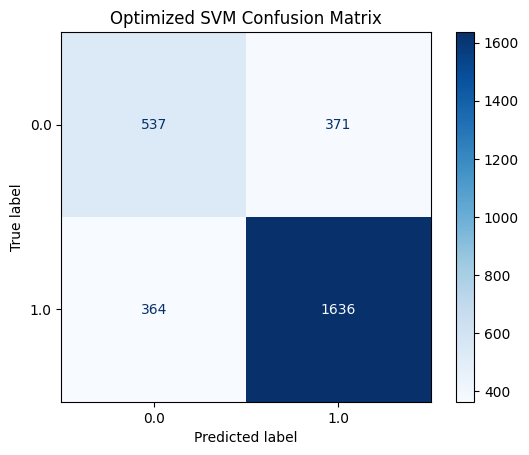

In [71]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt


cm = confusion_matrix(y_test, y_pred, labels=best_svm.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_svm.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Optimized SVM Confusion Matrix")
plt.show()


In [72]:
!pip install transformers datasets torch


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [73]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch


MODEL_NAME = "sagorsarker/bangla-bert-base"  # Bangla BERT
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)

c:\Users\User\Desktop\Bangla_Fake_News_detection\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at sagorsarker/bangla-bert-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [77]:
from torch.utils.data import Dataset

class BanglaNewsDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts.iloc[idx])
        label = self.labels.iloc[idx]
        encoding = self.tokenizer(
            text,
            padding='max_length',
            truncation=True,
            max_length=self.max_len,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }


In [87]:
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121


Looking in indexes: https://download.pytorch.org/whl/cu121


ERROR: Could not find a version that satisfies the requirement torchaudio (from versions: none)

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: No matching distribution found for torchaudio


In [89]:
!pip uninstall torch torchvision torchaudio -y


Found existing installation: torch 2.9.1
Uninstalling torch-2.9.1:
  Successfully uninstalled torch-2.9.1


You can safely remove it manually.


In [90]:
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121


Looking in indexes: https://download.pytorch.org/whl/cu121


ERROR: Could not find a version that satisfies the requirement torch (from versions: none)

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: No matching distribution found for torch


In [92]:
import sys
print(sys.executable)


c:\Users\User\Desktop\Bangla_Fake_News_detection\.venv\Scripts\python.exe


In [100]:
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from torch.optim import AdamW

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from tqdm import tqdm

new_data = pd.read_csv("newDataset.csv")

X_train, X_test, y_train, y_test = train_test_split(
    new_data['content'],
    new_data['label'],
    test_size=0.2,
    random_state=42,
    stratify=new_data['label']
)

#  Bangla BERT
MODEL_NAME = "sagorsarker/bangla-bert-base"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

class BanglaNewsDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts.iloc[idx])
        label = self.labels.iloc[idx]
        encoding = self.tokenizer(
            text,
            padding='max_length',
            truncation=True,
            max_length=self.max_len,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }


train_dataset = BanglaNewsDataset(X_train, y_train, tokenizer)
test_dataset = BanglaNewsDataset(X_test, y_test, tokenizer)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16)


optimizer = AdamW(model.parameters(), lr=2e-5)


epochs = 1

for epoch in range(epochs):
    model.train()
    loop = tqdm(train_loader, leave=True)
    for batch in loop:
        optimizer.zero_grad()
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        loss.backward()
        optimizer.step()

        loop.set_description(f'Epoch {epoch+1}')
        loop.set_postfix(loss=loss.item())


model.eval()
y_pred = []
y_true = []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        preds = torch.argmax(outputs.logits, dim=1)

        y_pred.extend(preds.cpu().numpy())
        y_true.extend(labels.cpu().numpy())

print("Classification Report on Test Set:")
print(classification_report(y_true, y_pred))

#  Saving the fine-tuned model
model.save_pretrained("Bert_On_newData")

import gc

# free unused memory to release file locks
torch.cuda.empty_cache()
gc.collect()

SAVE_DIR = "bangla_bert_fake_news_v4"  


model.save_pretrained(SAVE_DIR, safe_serialization=False)
tokenizer.save_pretrained(SAVE_DIR)

print(f" Model and tokenizer saved successfully to '{SAVE_DIR}'")

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at sagorsarker/bangla-bert-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Epoch 1: 100%|██████████| 727/727 [47:55<00:00,  3.96s/it, loss=0.492]


Classification Report on Test Set:
              precision    recall  f1-score   support

           0       0.58      0.41      0.48       908
           1       0.76      0.86      0.81      2000

    accuracy                           0.72      2908
   macro avg       0.67      0.64      0.64      2908
weighted avg       0.71      0.72      0.71      2908



ModuleNotFoundError: No module named 'torch.utils.serialization'

In [29]:
#random forest
import pandas as pd
import pickle
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Load dataset
data = pd.read_csv("New_dataset_preprocessed.csv")
texts = data['text']       
labels = data['label']     

# Load TF-IDF vectorizer
with open("tfidf_vectorizer.pkl", "rb") as f:
    vectorizer = pickle.load(f)

X = vectorizer.transform(texts)
y = labels.values

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Random Forest with balanced class weights
rf = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42)
rf.fit(X_train, y_train)

# Predict
y_pred = rf.predict(X_test)

# Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))



Accuracy: 0.731604765241766
Confusion Matrix:
 [[ 974  466]
 [ 300 1114]]
Classification Report:
               precision    recall  f1-score   support

           0       0.76      0.68      0.72      1440
           1       0.71      0.79      0.74      1414

    accuracy                           0.73      2854
   macro avg       0.73      0.73      0.73      2854
weighted avg       0.74      0.73      0.73      2854



In [83]:

!pip install xgboost


   ---------------------------------------- 0.0/72.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/72.0 MB ? eta -:--:--
   ---------------------------------------- 0.5/72.0 MB 1.9 MB/s eta 0:00:38
    --------------------------------------- 1.0/72.0 MB 2.2 MB/s eta 0:00:33
    --------------------------------------- 1.6/72.0 MB 2.1 MB/s eta 0:00:33
   - -------------------------------------- 2.1/72.0 MB 2.2 MB/s eta 0:00:32
   - -------------------------------------- 2.4/72.0 MB 2.1 MB/s eta 0:00:33
   - -------------------------------------- 2.9/72.0 MB 2.2 MB/s eta 0:00:32
   - -------------------------------------- 3.4/72.0 MB 2.2 MB/s eta 0:00:31
   -- ------------------------------------- 4.2/72.0 MB 2.4 MB/s eta 0:00:28
   --- ------------------------------------ 5.8/72.0 MB 3.0 MB/s eta 0:00:23
   --- ------------------------------------ 7.1/72.0 MB 3.3 MB/s eta 0:00:20
   ---- ----------------------------------- 8.1/72.0 MB 3.6 MB/s eta 0:00:18
   ----- ----


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [27]:
#Xgboost
import xgboost as xgb
import pandas as pd
import pickle
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import xgboost as xgb

# 1Load processed dataset
data = pd.read_csv("New_dataset_preprocessed.csv") 
texts = data['text']    
labels = data['label']  

#  Load TF-IDF vectorizer
with open("tfidf_vectorizer.pkl", "rb") as f:
    vectorizer = pickle.load(f)

# Transform texts to TF-IDF features
X = vectorizer.transform(texts)
y = labels.values

#  Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#  Train XGBoost model
model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=10,
    scale_pos_weight=5,  # balances minority class
    random_state=42
)
model.fit(X_train, y_train)

# Predict and evaluate
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.7368605466012614
Confusion Matrix:
 [[ 920  520]
 [ 231 1183]]
Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.64      0.71      1440
           1       0.69      0.84      0.76      1414

    accuracy                           0.74      2854
   macro avg       0.75      0.74      0.73      2854
weighted avg       0.75      0.74      0.73      2854



In [34]:
#Xgboost fine-tuned
import xgboost as xgb
import pandas as pd
import pickle
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


data = pd.read_csv("New_dataset_processed.csv")  
texts = data['text']    
labels = data['label']     

#  Load TF-IDF vectorizer
with open("tfidf_vectorizer.pkl", "rb") as f:
    vectorizer = pickle.load(f)

# Transform texts to TF-IDF features
X = vectorizer.transform(texts)
y = labels.values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Def XGBoost classifier
xgb_model = xgb.XGBClassifier(
    n_estimators=500,      
    max_depth=8,           
    learning_rate=0.05,    
    scale_pos_weight=(y_train==0).sum() / (y_train==1).sum(), 
    subsample=0.8,       
    colsample_bytree=0.8,  
    eval_metric='logloss',
    use_label_encoder=False,
    random_state=42
)


# train 
xgb_model.fit(X_train, y_train)

#  Predict and evaluate
y_pred = xgb_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred, digits=4))

# 8. Save model 
with open("xgb_model.pkl", "wb") as f:
    pickle.dump(xgb_model, f)


c:\Users\User\Desktop\Bangla_Fake_News_detection\.venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [22:16:56] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy: 0.7659425367904695
Confusion Matrix:
 [[1039  388]
 [ 280 1147]]
Classification Report:
               precision    recall  f1-score   support

           0     0.7877    0.7281    0.7567      1427
           1     0.7472    0.8038    0.7745      1427

    accuracy                         0.7659      2854
   macro avg     0.7675    0.7659    0.7656      2854
weighted avg     0.7675    0.7659    0.7656      2854



In [ ]:
#Logistic reg
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from imblearn.over_sampling import RandomOverSampler
from scipy.sparse import hstack
from collections import Counter
import numpy as np

# Load dataset
new_data = pd.read_csv("New_dataset_preprocessed.csv")

X = new_data["text"]
y = new_data["label"]

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# TF-IDF WORD
word_vec = TfidfVectorizer(
    analyzer="word", 
    ngram_range=(1,2), 
    max_features=20000
)
X_train_w = word_vec.fit_transform(X_train)
X_test_w = word_vec.transform(X_test)

# TF-IDF CHAR
char_vec = TfidfVectorizer(
    analyzer="char",
    ngram_range=(3,5),
    max_features=8000
)
X_train_c = char_vec.fit_transform(X_train)
X_test_c = char_vec.transform(X_test)

# Combine features
X_train_final = hstack([X_train_w, X_train_c])
X_test_final = hstack([X_test_w, X_test_c])

# Oversampling
ros = RandomOverSampler(random_state=42)
X_train_final, y_train = ros.fit_resample(X_train_final, y_train)

print("After oversampling:", Counter(y_train))

# Train Linear SVM (VERY FAST)
svm = LinearSVC(C=1)
svm.fit(X_train_final, y_train)

# Train Logistic Regression 
lr = LogisticRegression(max_iter=2000, C=1)
lr.fit(X_train_final, y_train)

# Predictions
svm_pred = svm.predict(X_test_final)
lr_pred = lr.predict(X_test_final)

# Majority vote
final_pred = np.where(svm_pred == lr_pred, svm_pred, svm_pred)

# Evaluation
print("Accuracy:", accuracy_score(y_test, final_pred))
print(classification_report(y_test, final_pred))


After oversampling: Counter({0: 5707, 1: 5707})
Accuracy: 0.7894183601962158
              precision    recall  f1-score   support

           0       0.79      0.80      0.79      1427
           1       0.79      0.78      0.79      1427

    accuracy                           0.79      2854
   macro avg       0.79      0.79      0.79      2854
weighted avg       0.79      0.79      0.79      2854



In [32]:
import xgboost as xgb
import pandas as pd
import pickle
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import xgboost as xgb

# 1Load processed dataset
new_data = pd.read_csv("New_dataset_processed.csv")  
new_data = new_data[['text', 'label']]
data = new_data.dropna(subset=['text', 'label'])
texts = data['text']    
labels = data['label']  

#  Load TF-IDF vectorizer
with open("tfidf_vectorizer.pkl", "rb") as f:
    vectorizer = pickle.load(f)

# Transform texts to TF-IDF features
X = vectorizer.transform(texts)
y = labels.values

#  Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#  Train XGBoost model
model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=10,
    scale_pos_weight=5,  # balances minority class
    random_state=42
)
model.fit(X_train, y_train)

# Predict and evaluate
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.7368605466012614
Confusion Matrix:
 [[ 920  520]
 [ 231 1183]]
Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.64      0.71      1440
           1       0.69      0.84      0.76      1414

    accuracy                           0.74      2854
   macro avg       0.75      0.74      0.73      2854
weighted avg       0.75      0.74      0.73      2854



In [5]:
# 1. Make sure new_data is cleaned (only text & label, no NaN)
new_data = new_data[['text', 'label']]
new_data = new_data.dropna(subset=['text', 'label'])

# 2. Load TF-IDF vectorizer
import pickle
with open("tfidf_vectorizer.pkl", "rb") as f:
    vectorizer = pickle.load(f)

# 3. Transform text
X_new = vectorizer.transform(new_data['text'])
y_new = new_data['label'].values

# 4. Load trained XGBoost model (or retrain if needed)
with open("xgb_model.pkl", "rb") as f:
    model = pickle.load(f)

# 5. Predict
y_new_pred = model.predict(X_new)

results_df = pd.DataFrame({
    'text': new_data['text'],
    'true_label': y_new,
    'predicted_label': y_new_pred
})

results_df.head(10)  # first 10 rows


,text,true_label,predicted_label
0,ঝিনাইদহে দুই পক্ষের গোলাগুলিতে নিহত ১ ঝিনাইদহে...,1,1
1,ফরিদপুরে ‘অশ্লীল’ ভিডিওসহ আটক ৫ র‌্যাব ৮-এর ফর...,1,1
2,কারাগার থেকে মুক্ত হলেন নওয়াজ ও তার মেয়ে ১৯ সে...,1,0
3,রোহিঙ্গা নারীকে পাচারের অভিযোগে একজনকে কারাদণ্...,1,1
4,শার্শায় গুচ্ছ গ্রামের স্থান পরিদর্শনে উপসচিব অ...,1,0
5,কুমিল্লা বিদ্যুতের তার ছিঁড়ে পড়ে ৪ জনের মৃত্যু...,1,1
6,‘আলিয়ার চুম্বন কিছুতেই ভোলার মতো নয়’ বলিউডের অ...,1,0
7,ট্রাম্পের সঙ্গে ফের বৈঠক চান কিম উত্তর কোরিয়ার...,1,0
8,গুজব শনাক্ত সেলের কার্যক্রম শুরু হবে আগামী মাস...,1,1
9,ন্যায় বিচার প্রতিষ্ঠায় মেডিয়েশন পদ্ধতির ভূমিকা...,1,1


In [31]:

!pip install bangla-stemmer  

import pandas as pd
import re
import string
from bangla_stemmer.stemmer import stemmer

# Bangla stopwords list (keep your full list)
bangla_stopwords = set([  # CHANGED: converted to set for faster lookup
    'অবশ্য','অনেক','অনেকে','অনেকেই','অন্তত','অন্য','আজ','আছে','আপনার','আপনি',
'আবার','আমরা','আমাকে','আমাদের','আমার','আমি','আরও','আর','আগে','আগেই','আই',
'অতএব','আগামী','অবধি','অনুযায়ী','আদ্যভাগে','এই','একই','একে','একটি','এখন',
'এখনও','এখানে','এখানেই','এটি','এটা','এটাই','এতটাই','এবং','একবার','এবার',
'এদের','এঁদের','এমন','এমনকী','এল','এর','এরা','এঁরা','এস','এতে','এসে','এ',
'ঐ','ই','ইহা','ইত্যাদি','উনি','উপর','উপরে','উচিত','ও','ওই','ওর','ওরা','ওঁর',
'ওঁরা','ওকে','ওদের','ওঁদের','ওখানে','কত','কবে','করতে','কয়েক','কয়েকটি','করবে',
'করলেন','করার','কারও','করা','করি','করিয়ে','করাই','করলে','করিতে','করিয়া','করেছিলেন',
'করছে','করছেন','করেছেন','করেছে','করেন','করবেন','করায়','করে','করেই','কাছ','কাছে',
'কাজে','কারণ','কিছু','কিছুই','কিন্তু','কিংবা','কি','কী','কেউ','কেউই','কাউকে','কেন',
'কে','কোনও','কোনো','কোন','কখনও','ক্ষেত্রে','খুব','গুলি','গিয়ে','গিয়েছে','গেছে',
'গেল','গেলে','গোটা','চলে','ছাড়া','ছাড়াও','ছিলেন','ছিল','জন্য','জানা','ঠিক','তিনি',
'তিনঐ','তিনিও','তখন','তবে','তবু','তাঁদের','তাঁরা','তাঁর','তাঁকে','তাই','তেমন','তাকে',
'তাহা','তাহাতে','তাহার','তাদের','তারপর','তারা','তার','তাহলে','তা','তাও','তাতে','তো',
'তত','তুমি','তোমার','তথা','থাকে','থাকা','থাকায়','থেকে','থেকেও','থাকবে','থাকেন',
'থাকবেন','থেকেই','দিকে','দিতে','দিয়ে','দিয়েছে','দিয়েছেন','দিলেন','দু','দুটি','দুটো',
'দেয়','দেওয়া','দেওয়ার','দেখা','দেখে','দেখতে','দ্বারা','ধরে','ধরা','নয়','নানা','না',
'নাকি','নাগাদ','নিতে','নিজে','নিজেই','নিজের','নিজেদের','নিয়ে','নেওয়া','নেওয়ার','নেই',
'নাই','পক্ষে','পর্যন্ত','পাওয়া','পারেন','পারি','পারে','পরে','পরেই','পরেও','পর','পেয়ে',
'প্রতি','প্রভৃতি','প্রায়','ফের','ফলে','ব্যবহার','বলতে','বললেন','বলেছেন','বলল','বলা',
'বলেন','বলে','বহু','বসে','বার','বা','বিনা','বরং','বদলে','বাদে','বিশেষ','বিভিন্ন',
'বিষয়টি','ব্যাপারে','ভাবে','ভাবেই','মধ্যে','মধ্যেই','মধ্যেও','মধ্যভাগে','মাধ্যমে','মাত্র',
'মতো','মতোই','মোটেই','যখন','যদি','যদিও','যাবে','যায়','যাকে','যাওয়া','যাওয়ার','যত',
'যতটা','যা','যার','যারা','যাঁর','যাঁরা','যাদের','যান','যাচ্ছে','যেতে','যাতে','যেন','যেমন',
'যেখানে','যিনি','যে','রেখে','রাখা','রয়েছে','রকম','শুধু','সঙ্গে','সঙ্গেও','সমস্ত','সব',
'সবার','সহ','সুতরাং','সহিত','সেই','সেটা','সেটি','সেটাই','সেটাও','সম্প্রতি','সেখান',
'সেখানে','সে','স্পষ্ট','স্বয়ং','হইতে','হইবে','হৈলে','হইয়া','হচ্ছে','হত','হতে','হতেই',
'হবে','হবেন','হয়েছিল','হয়েছে','হয়েছেন','হয়ে','হয়নি','হয়','হয়েই','হয়তো','হল','হলে',
'হলেই','হলেও','হলো','হিসাবে','হওয়া','হওয়ার','হওয়ায়','হন','হোক','জন','জনকে','জনের',
'জানতে','জানায়','জানিয়ে','জানানো','জানিয়েছে','জন্য','জন্যওজে','জে','বেশ','দেন','তুলে',
'ছিলেন','চান','চায়','চেয়ে','মোট','যথেষ্ট','টি','অনুযায়ী','উত্তর','কমনে','প্রথম','প্রযন্ত',
'প্রাথমিক','মনে','নতুন','পি','পেয়্র্','বক্তব্য','ধামার','সি','সাধারণ','সামনে','হাজার'
])

# Simple stemmer for common suffixes (same as your function)
def simple_bangla_stem(word):
    suffixes = ["গুলো", "দের", "মতো", "গুলোই", "টিতে", "টার", "রা", "টি", "টা", "তে", "র", "এর", "ই", "ও"]
    for suf in sorted(suffixes, key=len, reverse=True):
        if word.endswith(suf) and len(word) > len(suf) + 1:
            return word[:-len(suf)]
    return word


bangla_normalization_dict = {
    "মুরগি": "মুরগি",
    "মুরগী": "মুরগি",
    "মুরগীটা": "মুরগি",
    "মুরগিটা": "মুরগি",
    "মুরগিগুলো": "মুরগি",
    "শিয়াল": "শিয়াল",
    "শেয়াল": "শিয়াল",
    "শিয়ালটা": "শিয়াল",
    "শিয়ালগুলো": "শিয়াল",
    "শিয়াল": "শিয়াল",
    "মানুষ": "মানুষ",
    "মাঞ্জুষ": "মানুষ",
    "মানুষটা": "মানুষ",
    "মানুষগুলো": "মানুষ",
    "ইন্টারভিউ": "ইন্টারভিউ",
    "ক্যামেরাম্যান": "ক্যামেরাম্যান",
    "মডেল": "মডেল",
    "টিম": "টিম",
    "বস": "বস",
    "ভিডি": "ভিডিও",
    "ভিডিও": "ভিডিও",
    "ফরান্স": "ফ্রান্স",
    "ফ্রান্স": "ফ্রান্স",
    "খাচ্ছে": "খাওয়া",
    "খাচ্ছেন": "খাওয়া",
    "খায়": "খাওয়া",
    "খেতে": "খাওয়া",
    "খেয়েছে": "খাওয়া",
    "দেয়": "দেওয়া",
    "দিচ্ছে": "দেওয়া",
    "দিয়েছে": "দেওয়া",
    "একটি": "এক",
    "এক": "এক",
    "দুইটি": "দুই",
    "দুই": "দুই",
    "তিনটি": "তিন",
    "তিন": "তিন",
    "চারটি": "চার",
    "চার": "চার",
    "পাঁচটি": "পাঁচ",
    "পাঁচ": "পাঁচ",
    "ছেলে": "ছেলে",
    "মেয়ে": "মেয়ে",
    "মেয়ে": "মেয়ে",
    "বাবা": "বাবা",
    "মা": "মা",
    "ছেলেটি": "ছেলে",
    "মেয়েটি": "মেয়ে",
    "বইটি": "বই",
    "বই": "বই",
    "ঘরটা": "ঘর",
    "ঘর": "ঘর",
    "স্কুল": "স্কুল",
    "বিদ্যালয়": "বিদ্যালয়",
}


# Suppress print outputs from stemmer
import sys, io
def suppress_stdout(func, *args, **kwargs):
    old_stdout = sys.stdout
    sys.stdout = io.StringIO()
    try:
        result = func(*args, **kwargs)
    finally:
        sys.stdout = old_stdout
    return result

# Main preprocessing function
def preprocessNew_bangla_text(text):
    text = str(text)

    # Remove HTML, URLs, emails, hashtags, Latin letters, and numbers
    text = re.sub(r"<.*?>|http\S+|www\S+|\S*@\S*|\#\S*", " ", text)  # CHANGED: combined into one regex
    text = re.sub(r"[a-zA-Z০-৯0-9]+", " ", text)  # CHANGED: removed unnecessary parts

    # Remove punctuation
    punct_pattern = f"[{string.punctuation}।॥‘’“”—৳]"  # CHANGED: unified punctuation
    text = re.sub(punct_pattern, " ", text)

    # Normalize certain characters
    text = re.sub("[য়য়]", "য়", text)
    text = re.sub("[ঋৃ]", "ঋ", text)
    text = re.sub("[ঁ্]", "", text)
    text = re.sub(r"\s+", " ", text).strip()  # CHANGED: condensed whitespace cleanup

    # Remove consecutive repeated words
    words = text.split()
    words = [words[i] for i in range(len(words)) if i == 0 or words[i] != words[i-1]]  # CHANGED: list comprehension

    # Normalize words using dictionary
    words = [bangla_normalization_dict.get(w, w) for w in words]  # CHANGED: more pythonic

    # Remove stopwords
    words = [w for w in words if w not in bangla_stopwords]  # CHANGED: set lookup faster

    # Apply simple stemming
    words = [simple_bangla_stem(w) for w in words]

    return " ".join(words)

# Load dataset
new_data = pd.read_csv("New_dataset.csv")
new_data = new_data[['text', 'label']]
# Apply preprocessing
new_data['text'] = new_data['text'].apply(preprocessNew_bangla_text) 
new_data['text'] = new_data['text'].str.strip()  # remove any leading/trailing spaces
new_data = new_data[new_data['text'] != ""]

# Check again
print(new_data.isnull().sum())
print("Empty text rows:", (new_data['text'] == "").sum())


# Preview results
for original, processed in zip(new_data['text'][:5], new_data['text'][:5]):  
    print("Original:", original)
    print("Processed:", processed)
    print("-" * 50)
    # Save the preprocessed dataset
    new_data = new_data[['text', 'label']]
new_data.to_csv("New_dataset_processed.csv", index=False)
print(" Preprocessed new dataset saved!")





[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


text     0
label    0
dtype: int64
Empty text rows: 0
Original: ঝিনাইদহে দু পকষে গোলাগুলি নিহত ঝিনাইদহে কোটচাদপুরে বলুহরে মাদক বয়বসায়ী দু পকষে গোলাগুলি একজন নিহত পুলিশে দাবি নিহত সেলিম মাদক বয়বসায়ী গত রাত দুই ঘটনা ঘটে পুলিশ সেলিমে বিরুদধে মাদক অপহরণে মামলা রা বলুহরে গোলাগুলি শবদ শুনে টহলে য়ায় পুলিশ অবসথান টে পালিয়ে য়ায় মাদক বয়বসায়ী ঘটনাসথল একজনে মরদেহ উদধা এছাড়া অসত মাদক জবদ সেলিমে মরদেহ সনাকত সথানীয় এমবি
Processed: ঝিনাইদহে দু পকষে গোলাগুলি নিহত ঝিনাইদহে কোটচাদপুরে বলুহরে মাদক বয়বসায়ী দু পকষে গোলাগুলি একজন নিহত পুলিশে দাবি নিহত সেলিম মাদক বয়বসায়ী গত রাত দুই ঘটনা ঘটে পুলিশ সেলিমে বিরুদধে মাদক অপহরণে মামলা রা বলুহরে গোলাগুলি শবদ শুনে টহলে য়ায় পুলিশ অবসথান টে পালিয়ে য়ায় মাদক বয়বসায়ী ঘটনাসথল একজনে মরদেহ উদধা এছাড়া অসত মাদক জবদ সেলিমে মরদেহ সনাকত সথানীয় এমবি
--------------------------------------------------
Original: ফরিদপুরে অশলীল ভিডিওসহ আটক র‌য়াব ফরিদপু কয়ামপে কোমপানি অধিনায়ক মো রইছ উদদিন জানান বুধবা বিকালে শহরে চুনাঘা বেড়িবাধ এলাকা শহরতলি বারী পলাজায় কমপিউ দোকানে অভিয়ান চালিয়ে আটক হলে

In [ ]:

import pandas as pd
import xgboost as xgb
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report




new_data = new_data[['text', 'label']]

# Drop rows with missing text/label
new_data = new_data.dropna(subset=['text', 'label']).reset_index(drop=True)




vectorizer = TfidfVectorizer(max_features=50000, ngram_range=(1,2))
X = vectorizer.fit_transform(new_data['text'])
y = new_data['label'].astype(int).values


X_train, X_test, y_train, y_test, X_train_text, X_test_text = train_test_split(
    X, y, new_data['text'], test_size=0.2, random_state=42, stratify=y
)


# Train XGBoost

model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=10,
    learning_rate=0.1,
    scale_pos_weight=1,   # dataset is balanced
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)
model.fit(X_train, y_train)


y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))


#  results table

results_df = pd.DataFrame({
    'text': X_test_text.reset_index(drop=True),
    'true_label': y_test,
    'predicted_label': y_pred
})

# Display first 10 rows in notebook
pd.set_option('display.max_colwidth', None)  # show full text
results_df.head(10)


results_df.to_csv("merged_dataset_predictions.csv", index=False)


c:\Users\User\Desktop\Bangla_Fake_News_detection\.venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [21:24:17] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy: 0.7883672039243167
Confusion Matrix:
 [[1110  317]
 [ 287 1140]]
Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.78      0.79      1427
           1       0.78      0.80      0.79      1427

    accuracy                           0.79      2854
   macro avg       0.79      0.79      0.79      2854
weighted avg       0.79      0.79      0.79      2854



In [15]:
import pandas as pd

# Load your new dataset
new_data = pd.read_csv("new_dataset.csv")

# Keep only text and label columns, drop missing values
new_data = new_data[['text', 'label']].dropna()
new_data = new_data[new_data['text'].str.strip() != '']

print(new_data.shape)
print(new_data.head())


(14269, 2)
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             

In [1]:
!pip install transformers datasets torch scikit-learn



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import re
import string
import pandas as pd

bangla_stopwords = set([
    'অবশ্য','অনেক','অনেকে','অনেকেই','অন্তত','অন্য','আজ','আছে','আপনার','আপনি',
'আবার','আমরা','আমাকে','আমাদের','আমার','আমি','আরও','আর','আগে','আগেই','আই',
'অতএব','আগামী','অবধি','অনুযায়ী','আদ্যভাগে','এই','একই','একে','একটি','এখন',
'এখনও','এখানে','এখানেই','এটি','এটা','এটাই','এতটাই','এবং','একবার','এবার',
'এদের','এঁদের','এমন','এমনকী','এল','এর','এরা','এঁরা','এস','এতে','এসে','এ',
'ঐ','ই','ইহা','ইত্যাদি','উনি','উপর','উপরে','উচিত','ও','ওই','ওর','ওরা','ওঁর',
'ওঁরা','ওকে','ওদের','ওঁদের','ওখানে','কত','কবে','করতে','কয়েক','কয়েকটি','করবে',
'করলেন','করার','কারও','করা','করি','করিয়ে','করাই','করলে','করিতে','করিয়া','করেছিলেন',
'করছে','করছেন','করেছেন','করেছে','করেন','করবেন','করায়','করে','করেই','কাছ','কাছে',
'কাজে','কারণ','কিছু','কিছুই','কিন্তু','কিংবা','কি','কী','কেউ','কেউই','কাউকে','কেন',
'কে','কোনও','কোনো','কোন','কখনও','ক্ষেত্রে','খুব','গুলি','গিয়ে','গিয়েছে','গেছে',
'গেল','গেলে','গোটা','চলে','ছাড়া','ছাড়াও','ছিলেন','ছিল','জন্য','জানা','ঠিক','তিনি',
'তিনঐ','তিনিও','তখন','তবে','তবু','তাঁদের','তাঁরা','তাঁর','তাঁকে','তাই','তেমন','তাকে',
'তাহা','তাহাতে','তাহার','তাদের','তারপর','তারা','তার','তাহলে','তা','তাও','তাতে','তো',
'তত','তুমি','তোমার','তথা','থাকে','থাকা','থাকায়','থেকে','থেকেও','থাকবে','থাকেন',
'থাকবেন','থেকেই','দিকে','দিতে','দিয়ে','দিয়েছে','দিয়েছেন','দিলেন','দু','দুটি','দুটো',
'দেয়','দেওয়া','দেওয়ার','দেখা','দেখে','দেখতে','দ্বারা','ধরে','ধরা','নয়','নানা','না',
'নাকি','নাগাদ','নিতে','নিজে','নিজেই','নিজের','নিজেদের','নিয়ে','নেওয়া','নেওয়ার','নেই',
'নাই','পক্ষে','পর্যন্ত','পাওয়া','পারেন','পারি','পারে','পরে','পরেই','পরেও','পর','পেয়ে',
'প্রতি','প্রভৃতি','প্রায়','ফের','ফলে','ব্যবহার','বলতে','বললেন','বলেছেন','বলল','বলা',
'বলেন','বলে','বহু','বসে','বার','বা','বিনা','বরং','বদলে','বাদে','বিশেষ','বিভিন্ন',
'বিষয়টি','ব্যাপারে','ভাবে','ভাবেই','মধ্যে','মধ্যেই','মধ্যেও','মধ্যভাগে','মাধ্যমে','মাত্র',
'মতো','মতোই','মোটেই','যখন','যদি','যদিও','যাবে','যায়','যাকে','যাওয়া','যাওয়ার','যত',
'যতটা','যা','যার','যারা','যাঁর','যাঁরা','যাদের','যান','যাচ্ছে','যেতে','যাতে','যেন','যেমন',
'যেখানে','যিনি','যে','রেখে','রাখা','রয়েছে','রকম','শুধু','সঙ্গে','সঙ্গেও','সমস্ত','সব',
'সবার','সহ','সুতরাং','সহিত','সেই','সেটা','সেটি','সেটাই','সেটাও','সম্প্রতি','সেখান',
'সেখানে','সে','স্পষ্ট','স্বয়ং','হইতে','হইবে','হৈলে','হইয়া','হচ্ছে','হত','হতে','হতেই',
'হবে','হবেন','হয়েছিল','হয়েছে','হয়েছেন','হয়ে','হয়নি','হয়','হয়েই','হয়তো','হল','হলে',
'হলেই','হলেও','হলো','হিসাবে','হওয়া','হওয়ার','হওয়ায়','হন','হোক','জন','জনকে','জনের',
'জানতে','জানায়','জানিয়ে','জানানো','জানিয়েছে','জন্য','জন্যওজে','জে','বেশ','দেন','তুলে',
'ছিলেন','চান','চায়','চেয়ে','মোট','যথেষ্ট','টি','অনুযায়ী','উত্তর','কমনে','প্রথম','প্রযন্ত',
'প্রাথমিক','মনে','নতুন','পি','পেয়্র্','বক্তব্য','ধামার','সি','সাধারণ','সামনে','হাজার'
])  
bangla_normalization_dict = { "মুরগি": "মুরগি",
    "মুরগী": "মুরগি",
    "মুরগীটা": "মুরগি",
    "মুরগিটা": "মুরগি",
    "মুরগিগুলো": "মুরগি",
    "শিয়াল": "শিয়াল",
    "শেয়াল": "শিয়াল",
    "শিয়ালটা": "শিয়াল",
    "শিয়ালগুলো": "শিয়াল",
    "শিয়াল": "শিয়াল",
    "মানুষ": "মানুষ",
    "মাঞ্জুষ": "মানুষ",
    "মানুষটা": "মানুষ",
    "মানুষগুলো": "মানুষ",
    "ইন্টারভিউ": "ইন্টারভিউ",
    "ক্যামেরাম্যান": "ক্যামেরাম্যান",
    "মডেল": "মডেল",
    "টিম": "টিম",
    "বস": "বস",
    "ভিডি": "ভিডিও",
    "ভিডিও": "ভিডিও",
    "ফরান্স": "ফ্রান্স",
    "ফ্রান্স": "ফ্রান্স",
    "খাচ্ছে": "খাওয়া",
    "খাচ্ছেন": "খাওয়া",
    "খায়": "খাওয়া",
    "খেতে": "খাওয়া",
    "খেয়েছে": "খাওয়া",
    "দেয়": "দেওয়া",
    "দিচ্ছে": "দেওয়া",
    "দিয়েছে": "দেওয়া",
    "একটি": "এক",
    "এক": "এক",
    "দুইটি": "দুই",
    "দুই": "দুই",
    "তিনটি": "তিন",
    "তিন": "তিন",
    "চারটি": "চার",
    "চার": "চার",
    "পাঁচটি": "পাঁচ",
    "পাঁচ": "পাঁচ",
    "ছেলে": "ছেলে",
    "মেয়ে": "মেয়ে",
    "মেয়ে": "মেয়ে",
    "বাবা": "বাবা",
    "মা": "মা",
    "ছেলেটি": "ছেলে",
    "মেয়েটি": "মেয়ে",
    "বইটি": "বই",
    "বই": "বই",
    "ঘরটা": "ঘর",
    "ঘর": "ঘর",
    "স্কুল": "স্কুল",
    "বিদ্যালয়": "বিদ্যালয়",}  

def simple_bangla_stem(word):
    suffixes = ["গুলো", "দের", "মতো", "গুলোই", "টিতে", "টার", "রা", "টি", "টা", "তে", "র", "এর", "ই", "ও"]
    for suf in sorted(suffixes, key=len, reverse=True):
        if word.endswith(suf) and len(word) > len(suf) + 1:
            return word[:-len(suf)]
    return word

def preprocess_text(text):
    text = str(text)
    text = re.sub(r"<.*?>|http\S+|www\S+|\S*@\S*|\#\S*", " ", text)
    text = re.sub(r"[a-zA-Z০-৯0-9]+", " ", text)
    punct_pattern = f"[{string.punctuation}।॥‘’“”—৳]"
    text = re.sub(punct_pattern, " ", text)
    text = re.sub("[য়য়]", "য়", text)
    text = re.sub("[ঋৃ]", "ঋ", text)
    text = re.sub("[ঁ্]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    
    words = text.split()
    words = [words[i] for i in range(len(words)) if i == 0 or words[i] != words[i-1]]
    words = [bangla_normalization_dict.get(w, w) for w in words]
    words = [w for w in words if w not in bangla_stopwords]
    words = [simple_bangla_stem(w) for w in words]
    
    return " ".join(words)


In [4]:
# Old dataset
old_data = pd.read_csv("processed_data.csv")[['text', 'label']]
old_data['text'] = old_data['text'].apply(preprocess_text)

# New dataset
new_data = pd.read_csv("New_dataset.csv")[['text', 'label']]
new_data['text'] = new_data['text'].apply(preprocess_text)

# Combine datasets
combined_data = pd.concat([old_data, new_data], ignore_index=True)

# Optional: shuffle
combined_data = combined_data.sample(frac=1, random_state=42).reset_index(drop=True)


In [32]:
import pandas as pd
import pickle
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from imblearn.combine import SMOTETomek
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, accuracy_score
from collections import Counter

data = pd.read_csv("processed_data.csv")

# Reload your data
# Assuming processed_data is your dataset
X_text = data['text']
y = data['label']

# Split data first
X_train, X_test, y_train, y_test = train_test_split(
    X_text, y, test_size=0.2, random_state=42, stratify=y
)

# Improved TF-IDF vectorization
vectorizer = TfidfVectorizer(
    max_features=3000,
    ngram_range=(1, 2),
    min_df=3,           # Ignore terms that appear in less than 3 documents
    max_df=0.8,         # Ignore terms that appear in more than 80% of documents
    stop_words='english'
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("TF-IDF feature shape:", X_train_tfidf.shape)
print("First 20 features:", vectorizer.get_feature_names_out()[:20])

# Save the improved vectorizer
import os
os.makedirs("vectorizer", exist_ok=True)
with open("vectorizer/improved_tfidf_vectorizer.pkl", "wb") as f:
    pickle.dump(vectorizer, f)
print("Improved vectorizer saved!")

# Handle imbalanced data
smk = SMOTETomek(random_state=42)
X_resampled, y_resampled = smk.fit_resample(X_train_tfidf, y_train)

print("Original train label distribution:", Counter(y_train))
print("Resampled train label distribution:", Counter(y_resampled))

# Test multiple improved models
models = {
    'Logistic Regression (Regularized)': LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        C=0.1,  # Stronger regularization
        random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=100,
        max_depth=20,
        min_samples_split=10,
        class_weight='balanced',
        random_state=42
    ),
    'SVM': LinearSVC(
        class_weight='balanced',
        C=0.1,
        random_state=42,
        max_iter=1000
    )
}

# Evaluate each model
for name, model in models.items():
    print(f"\n{'='*50}")
    print(f"Training {name}...")
    
    # Cross-validation
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = cross_val_score(model, X_resampled, y_resampled, cv=cv, scoring='accuracy')
    print(f"Cross-validation Accuracy: {cv_scores.mean():.3f} (+/- {cv_scores.std() * 2:.3f})")
    
    # Train and test
    model.fit(X_resampled, y_resampled)
    y_pred = model.predict(X_test_tfidf)
    
    print(f"Test Accuracy: {accuracy_score(y_test, y_pred):.3f}")
    print(f"Classification Report for {name}:")
    print(classification_report(y_test, y_pred))

TF-IDF feature shape: (6800, 3000)
First 20 features: ['beats' 'bengal' 'bengal beats' 'eআরক' 'অক' 'অক বর' 'অগ' 'অগ রগত' 'অঙ'
 'অজ' 'অঞ' 'অঞ চল' 'অট' 'অট কশ' 'অড' 'অত' 'অত উপস' 'অত বক' 'অত যন' 'অত রম']
Improved vectorizer saved!
Original train label distribution: Counter({1: 5761, 0: 1039})
Resampled train label distribution: Counter({1: 5760, 0: 5760})

Training Logistic Regression (Regularized)...
Cross-validation Accuracy: 0.914 (+/- 0.015)
Test Accuracy: 0.904
Classification Report for Logistic Regression (Regularized):
              precision    recall  f1-score   support

           0       0.65      0.82      0.72       260
           1       0.97      0.92      0.94      1441

    accuracy                           0.90      1701
   macro avg       0.81      0.87      0.83      1701
weighted avg       0.92      0.90      0.91      1701


Training Random Forest...
Cross-validation Accuracy: 0.964 (+/- 0.011)
Test Accuracy: 0.938
Classification Report for Random Forest:
         

In [36]:
import pandas as pd
import pickle
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from imblearn.combine import SMOTETomek
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
import os


processed_data = pd.read_csv("processed_data.csv")

X_text = processed_data['text']
y = processed_data['label']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X_text, y, test_size=0.2, random_state=42, stratify=y
)

# Create and fit vectorizer
vectorizer = TfidfVectorizer(
    max_features=3000,
    ngram_range=(1, 2),
    min_df=3,
    max_df=0.8,
    stop_words='english'
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print(f"Training features shape: {X_train_tfidf.shape}")

# Handle class imbalance
smk = SMOTETomek(random_state=42)
X_resampled, y_resampled = smk.fit_resample(X_train_tfidf, y_train)

# Train improved model
print("Training improved model...")
improved_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    C=0.1,  # Regularization
    random_state=42
)

improved_model.fit(X_resampled, y_resampled)

# Test on original test set
y_pred = improved_model.predict(X_test_tfidf)
accuracy = accuracy_score(y_test, y_pred)
print(f"Model accuracy on test set: {accuracy:.3f}")

# Save the model and vectorizer
os.makedirs("models", exist_ok=True)
os.makedirs("vectorizer", exist_ok=True)

with open("models/improved_logreg_model.pkl", "wb") as f:
    pickle.dump(improved_model, f)

with open("vectorizer/tfidf_vectorizer.pkl", "wb") as f:
    pickle.dump(vectorizer, f)

print("Model and vectorizer saved successfully!")
print("Files created:")
print("- models/improved_logreg_model.pkl")
print("- vectorizer/tfidf_vectorizer.pkl")

Training features shape: (6800, 3000)
Training improved model...
Model accuracy on test set: 0.904
Model and vectorizer saved successfully!
Files created:
- models/improved_logreg_model.pkl
- vectorizer/tfidf_vectorizer.pkl


New data shape: (14268, 3000)

PREDICTION RESULTS ON NEW DATASET
Accuracy: 0.645
F1 Score: 0.611

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.35      0.50      7134
           1       0.59      0.94      0.73      7134

    accuracy                           0.65     14268
   macro avg       0.72      0.65      0.61     14268
weighted avg       0.72      0.65      0.61     14268


Confusion Matrix:
[[2488 4646]
 [ 419 6715]]


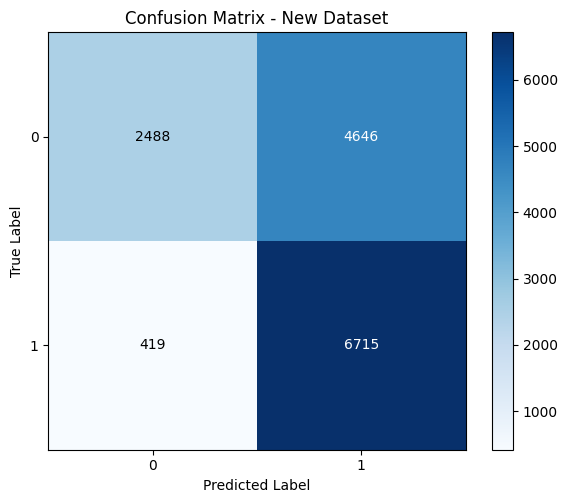

Misclassified samples: 5065/14268

Sample misclassifications:
  1. Text: অমিতাভ শাহরুখ কাতারে সানি লিওন অমিতাভ বচচন অনিল কাপু শাহরুখ খান সালমান খানে সঙগে এক সারি সানি লিওন র...
     True: 1, Predicted: 0, Confidence: 0.593
  2. Text: সেপটেমব হাস মানা জোকস সবামী মদ খাচছিল ঠাস শবদ করছিল শবদ শুনে সতরী বিরকত সতরী করছো সবামী মাছি মারছি স...
     True: 1, Predicted: 0, Confidence: 0.510
  3. Text: মালদবীপে চয়ামপিয়ন হারিয়ে পরসতুতি শুরু বসুনধ কিংসে নীলফামারী শেখ কামাল সটেডিয়ামে শুকরবা গোলে জিতেছে ব...
     True: 1, Predicted: 0, Confidence: 0.506

Testing completed!
Predictions saved to 'predictions_on_new_data.csv'


In [18]:
import pandas as pd
import pickle
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, f1_score
import matplotlib.pyplot as plt

def test_on_new_dataset(new_data_path):
    """
    Test the trained model on a completely new dataset
    """
    # Load model and vectorizer
    with open("vectorizer/tfidf_vectorizer.pkl", "rb") as f:
        vectorizer = pickle.load(f)
    
    with open("models/improved_logreg_model.pkl", "rb") as f:
        model = pickle.load(f)
    
    # Load new dataset
    
    new_data = pd.read_csv("New_dataset_processed.csv")
    
    # Check required columns
    if 'text' not in new_data.columns:
        print("Error: 'text' column not found in new dataset")
        print(f"Available columns: {new_data.columns.tolist()}")
        return
    
    # Preprocess text (same as training)
    def preprocess_text(text):
        if isinstance(text, str):
            return text.lower().strip()
        return ""
    
    new_data['processed_text'] = new_data['text'].apply(preprocess_text)
    
    # Transform using the saved vectorizer
    X_new = vectorizer.transform(new_data['processed_text'])
    print(f"New data shape: {X_new.shape}")
    
    # Make predictions
    predictions = model.predict(X_new)
    probabilities = model.predict_proba(X_new)
    
    # Add results to dataframe
    new_data['prediction'] = predictions
    new_data['confidence'] = np.max(probabilities, axis=1)
    
    print("\n" + "="*60)
    print("PREDICTION RESULTS ON NEW DATASET")
    print("="*60)
    
    # If true labels are available
    if 'label' in new_data.columns:
        accuracy = accuracy_score(new_data['label'], predictions)
        f1 = f1_score(new_data['label'], predictions, average='weighted')
        
        print(f"Accuracy: {accuracy:.3f}")
        print(f"F1 Score: {f1:.3f}")
        
        print("\nClassification Report:")
        print(classification_report(new_data['label'], predictions))
        
        # Simple confusion matrix without seaborn
        cm = confusion_matrix(new_data['label'], predictions)
        print("\nConfusion Matrix:")
        print(cm)
        
        # Plot simple confusion matrix
        plt.figure(figsize=(6, 5))
        plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
        plt.title('Confusion Matrix - New Dataset')
        plt.colorbar()
        
        # Add labels
        classes = model.classes_
        tick_marks = np.arange(len(classes))
        plt.xticks(tick_marks, classes)
        plt.yticks(tick_marks, classes)
        
        # Add text annotations
        thresh = cm.max() / 2.
        for i in range(cm.shape[0]):
            for j in range(cm.shape[1]):
                plt.text(j, i, format(cm[i, j], 'd'),
                        ha="center", va="center",
                        color="white" if cm[i, j] > thresh else "black")
        
        plt.ylabel('True Label')
        plt.xlabel('Predicted Label')
        plt.tight_layout()
        plt.show()
        
        # Misclassification analysis
        misclassified = new_data[new_data['label'] != new_data['prediction']]
        print(f"Misclassified samples: {len(misclassified)}/{len(new_data)}")
        
        if len(misclassified) > 0:
            print("\nSample misclassifications:")
            for i, (idx, row) in enumerate(misclassified.head(3).iterrows()):
                print(f"  {i+1}. Text: {row['text'][:100]}...")
                print(f"     True: {row['label']}, Predicted: {row['prediction']}, Confidence: {row['confidence']:.3f}")
    
    else:
        # No true labels - just show predictions
        print("Prediction Distribution:")
        pred_counts = pd.Series(predictions).value_counts().sort_index()
        for label, count in pred_counts.items():
            print(f"  Label {label}: {count} samples ({count/len(predictions):.1%})")
        
        print(f"\nConfidence Statistics:")
        print(f"  Average: {new_data['confidence'].mean():.3f}")
        print(f"  Minimum: {new_data['confidence'].min():.3f}")
        print(f"  Maximum: {new_data['confidence'].max():.3f}")
        
        # Show low confidence predictions
        low_conf = new_data[new_data['confidence'] < 0.6]
        if len(low_conf) > 0:
            print(f"  {len(low_conf)} samples with confidence < 0.6")
    
    return new_data

# Run the test
try:
    results = test_on_new_dataset('your_new_dataset.csv')  # Replace with your file path
    print("\nTesting completed!")
    
    # Save results
    results.to_csv('predictions_on_new_data.csv', index=False)
    print("Predictions saved to 'predictions_on_new_data.csv'")
    
except Exception as e:
    print(f"Error during testing: {e}")
    print("Please check:")
    print("1. The file path is correct")
    print("2. The file format is supported (CSV)")
    print("3. The file contains a 'text' column")

In [22]:
# Check if the new dataset has different characteristics
print("Training data label distribution:")
print(f"Class 0: {1039} samples")
print(f"Class 1: {5761} samples")
print(f"Ratio: 1:{5761/1039:.1f}")

print("\nNew dataset label distribution:")
print(f"Class 0: {7134} samples") 
print(f"Class 1: {7134} samples")
print(f"Ratio: 1:1 (balanced)")

processed_data = pd.read_csv("processed_data.csv")
new_data = pd.read_csv("New_dataset_processed.csv")
# Check text characteristics
print("\nTraining data text length stats:")
train_lengths = processed_data['text'].str.len()
print(f"Mean: {train_lengths.mean():.1f}, Std: {train_lengths.std():.1f}")

print("\nNew dataset text length stats:")
new_lengths = new_data['text'].str.len()
print(f"Mean: {new_lengths.mean():.1f}, Std: {new_lengths.std():.1f}")

Training data label distribution:
Class 0: 1039 samples
Class 1: 5761 samples
Ratio: 1:5.5

New dataset label distribution:
Class 0: 7134 samples
Class 1: 7134 samples
Ratio: 1:1 (balanced)

Training data text length stats:
Mean: 1742.5, Std: 1374.6

New dataset text length stats:
Mean: 1121.0, Std: 847.7


In [26]:
from sklearn.model_selection import train_test_split

# Since you have the true labels for new data, combine and balance
def create_balanced_training_set(original_data, new_data, target_ratio=1.0):
    """
    Create a balanced training set combining both datasets
    """
    # Combine both datasets
    combined_data = pd.concat([original_data, new_data], ignore_index=True)
    
    # Check combined distribution
    print("Combined data distribution:")
    print(combined_data['label'].value_counts())
    
    # Balance the dataset
    from sklearn.utils import resample
    
    # Separate classes
    class_0 = combined_data[combined_data['label'] == 0]
    class_1 = combined_data[combined_data['label'] == 1]
    
    # Determine target size (use the smaller class as reference)
    target_size = min(len(class_0), len(class_1))
    
    # Resample both classes to target size
    class_0_balanced = resample(class_0, 
                               replace=True,  # Allow sampling with replacement
                               n_samples=target_size, 
                               random_state=42)
    
    class_1_balanced = resample(class_1,
                               replace=False,  # Don't duplicate if we have enough
                               n_samples=target_size,
                               random_state=42)
    
    # Combine balanced classes
    balanced_data = pd.concat([class_0_balanced, class_1_balanced])
    
    # Shuffle
    balanced_data = balanced_data.sample(frac=1, random_state=42).reset_index(drop=True)
    
    print(f"Balanced dataset size: {len(balanced_data)}")
    print(f"Balanced distribution: {balanced_data['label'].value_counts().to_dict()}")
    
    return balanced_data

# Create balanced training data
balanced_data = create_balanced_training_set(processed_data, new_data)

# Retrain on balanced data
X_balanced = balanced_data['text']
y_balanced = balanced_data['label']

X_train_bal, X_test_bal, y_train_bal, y_test_bal = train_test_split(
    X_balanced, y_balanced, test_size=0.2, random_state=42, stratify=y_balanced
)

# Retrain vectorizer on balanced data
vectorizer_balanced = TfidfVectorizer(
    max_features=5000,  # Increased features to capture more patterns
    ngram_range=(1, 3),  # Added trigrams for better context
    min_df=2,
    max_df=0.9,
    stop_words=None
)

X_train_bal_tfidf = vectorizer_balanced.fit_transform(X_train_bal)
X_test_bal_tfidf = vectorizer_balanced.transform(X_test_bal)

print(f"Balanced training features: {X_train_bal_tfidf.shape}")

Combined data distribution:
label
1    14336
0     8433
Name: count, dtype: int64
Balanced dataset size: 16866
Balanced distribution: {0: 8433, 1: 8433}
Balanced training features: (13492, 5000)


In [28]:
# Train and evaluate multiple models on the balanced data
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from xgboost import XGBClassifier
import numpy as np

# Test multiple models on balanced data
models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, class_weight='balanced', C=0.1, random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=100, max_depth=20, class_weight='balanced', random_state=42
    ),
    'XGBoost': XGBClassifier(
        n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42, eval_metric='logloss'
    ),
    'SVM': SVC(
        class_weight='balanced', C=0.1, kernel='linear', random_state=42, probability=True
    ),
    'Naive Bayes': MultinomialNB(alpha=0.1)
}

# Evaluate each model
best_model = None
best_score = 0
best_model_name = ""

print(" TRAINING MODELS ON BALANCED DATA...")


for name, model in models.items():
    print(f"\n Training {name}...")
    
    # Train the model
    model.fit(X_train_bal_tfidf, y_train_bal)
    
    # Test on balanced test set
    y_pred_bal = model.predict(X_test_bal_tfidf)
    bal_accuracy = accuracy_score(y_test_bal, y_pred_bal)
    
    # Test on the complete new dataset (this is our target)
    X_new_bal = vectorizer_balanced.transform(new_data['text'])
    y_pred_new = model.predict(X_new_bal)
    new_accuracy = accuracy_score(new_data['label'], y_pred_new)
    
    print(f" Balanced Test Accuracy: {bal_accuracy:.3f}")
    print(f" New Dataset Accuracy: {new_accuracy:.3f}")
    
    # Store the best model
    if new_accuracy > best_score:
        best_score = new_accuracy
        best_model = model
        best_model_name = name
        best_vectorizer = vectorizer_balanced
    
    print(f" Classification Report on New Dataset:")
    print(classification_report(new_data['label'], y_pred_new))

print(f"\n{'='*70}")
print(f" BEST MODEL: {best_model_name}")
print(f" Accuracy on New Dataset: {best_score:.3f}")
print(f"{'='*70}")

# Save the best model
import joblib
joblib.dump(best_model, 'best_balanced_model.pkl')
joblib.dump(best_vectorizer, 'best_balanced_vectorizer.pkl')
print(" Best model and vectorizer saved!")

# Test the best model on a sample of new data
print("\n Testing best model on sample texts:")
sample_texts = new_data['text'].head(5).tolist()
sample_true = new_data['label'].head(5).tolist()

sample_features = best_vectorizer.transform(sample_texts)
sample_preds = best_model.predict(sample_features)
sample_proba = best_model.predict_proba(sample_features)

for i, (text, true, pred, proba) in enumerate(zip(sample_texts, sample_true, sample_preds, sample_proba)):
    confidence = max(proba)
    print(f"{i+1}. True: {true}, Pred: {pred}, Confidence: {confidence:.3f}")
    print(f"   Text: {text[:100]}...")
    print()

 TRAINING MODELS ON BALANCED DATA...

 Training Logistic Regression...
 Balanced Test Accuracy: 0.776
 New Dataset Accuracy: 0.690
 Classification Report on New Dataset:
              precision    recall  f1-score   support

           0       0.65      0.84      0.73      7134
           1       0.77      0.54      0.64      7134

    accuracy                           0.69     14268
   macro avg       0.71      0.69      0.68     14268
weighted avg       0.71      0.69      0.68     14268


 Training Random Forest...
 Balanced Test Accuracy: 0.814
 New Dataset Accuracy: 0.765
 Classification Report on New Dataset:
              precision    recall  f1-score   support

           0       0.70      0.94      0.80      7134
           1       0.90      0.59      0.72      7134

    accuracy                           0.77     14268
   macro avg       0.80      0.77      0.76     14268
weighted avg       0.80      0.77      0.76     14268


 Training XGBoost...
 Balanced Test Accuracy: 0.

 ANALYZING PREDICTION BIASES...


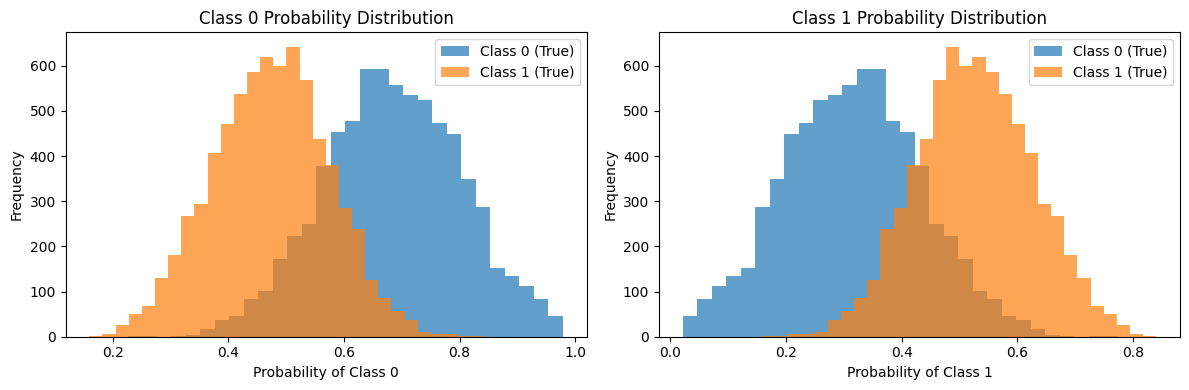

 Optimal threshold: 0.400
 Best F1 score: 0.826

 Optimized Performance:
              precision    recall  f1-score   support

           0       0.88      0.76      0.81      7134
           1       0.79      0.90      0.84      7134

    accuracy                           0.83     14268
   macro avg       0.83      0.83      0.83     14268
weighted avg       0.83      0.83      0.83     14268

Accuracy: 0.827


In [29]:

print(" ANALYZING PREDICTION BIASES...")

# Get detailed predictions for Random Forest (best model so far)
rf_model = models['Random Forest']
X_new_rf = vectorizer_balanced.transform(new_data['text'])
y_pred_proba = rf_model.predict_proba(X_new_rf)

# Analyze probability distributions
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(y_pred_proba[new_data['label'] == 0, 0], alpha=0.7, label='Class 0 (True)', bins=30)
plt.hist(y_pred_proba[new_data['label'] == 1, 0], alpha=0.7, label='Class 1 (True)', bins=30)
plt.xlabel('Probability of Class 0')
plt.ylabel('Frequency')
plt.legend()
plt.title('Class 0 Probability Distribution')

plt.subplot(1, 2, 2)
plt.hist(y_pred_proba[new_data['label'] == 0, 1], alpha=0.7, label='Class 0 (True)', bins=30)
plt.hist(y_pred_proba[new_data['label'] == 1, 1], alpha=0.7, label='Class 1 (True)', bins=30)
plt.xlabel('Probability of Class 1')
plt.ylabel('Frequency')
plt.legend()
plt.title('Class 1 Probability Distribution')

plt.tight_layout()
plt.show()

# Adjust decision threshold to improve Class 1 recall
def optimize_threshold(model, X, y_true):
    """Find optimal threshold to balance precision and recall"""
    from sklearn.metrics import f1_score
    y_proba = model.predict_proba(X)
    
    thresholds = np.arange(0.3, 0.7, 0.05)
    best_threshold = 0.5
    best_f1 = 0
    
    for threshold in thresholds:
        y_pred_adjusted = (y_proba[:, 1] > threshold).astype(int)
        f1 = f1_score(y_true, y_pred_adjusted, average='weighted')
        
        if f1 > best_f1:
            best_f1 = f1
            best_threshold = threshold
    
    return best_threshold, best_f1

optimal_threshold, optimal_f1 = optimize_threshold(rf_model, X_new_rf, new_data['label'])
print(f" Optimal threshold: {optimal_threshold:.3f}")
print(f" Best F1 score: {optimal_f1:.3f}")

# Apply optimal threshold
y_pred_optimized = (rf_model.predict_proba(X_new_rf)[:, 1] > optimal_threshold).astype(int)
print("\n Optimized Performance:")
print(classification_report(new_data['label'], y_pred_optimized))
print(f"Accuracy: {accuracy_score(new_data['label'], y_pred_optimized):.3f}")


In [31]:


# Save the threshold-optimized model
import joblib

def save_optimized_model(model, vectorizer, optimal_threshold=0.4):
    """Save model with optimal threshold"""
    model_data = {
        'model': model,
        'vectorizer': vectorizer,
        'optimal_threshold': optimal_threshold
    }
    joblib.dump(model_data, 'optimized_fake_news_model.pkl')
    print(" Optimized model saved with threshold 0.400")

# Save your current best setup
save_optimized_model(rf_model, vectorizer_balanced, 0.4)

# Prediction function with optimal threshold
def predict_with_threshold(texts, model_path='optimized_fake_news_model.pkl'):
    """Predict using the optimized threshold"""
    model_data = joblib.load(model_path)
    model = model_data['model']
    vectorizer = model_data['vectorizer']
    threshold = model_data['optimal_threshold']
    
    features = vectorizer.transform(texts)
    probabilities = model.predict_proba(features)
    
    # Use optimal threshold
    predictions = (probabilities[:, 1] > threshold).astype(int)
    confidences = np.max(probabilities, axis=1)
    
    results = []
    for i, (text, pred, prob, conf) in enumerate(zip(texts, predictions, probabilities, confidences)):
        results.append({
            'text': text,
            'prediction': pred,
            'confidence': conf,
            'probability_class_0': prob[0],
            'probability_class_1': prob[1],
            'label': 'Real' if pred == 1 else 'Fake'
        })
    
    return results

# Test the optimized predictor
test_texts = new_data['text'].head(3).tolist()
results = predict_with_threshold(test_texts)

print(" Optimized Predictor Results:")
for result in results:
    print(f"Text: {result['text'][:80]}...")
    print(f"Prediction: {result['label']} (Confidence: {result['confidence']:.3f})")
    print(f"Fake Prob: {result['probability_class_0']:.3f}, Real Prob: {result['probability_class_1']:.3f}")
    print()

 Optimized model saved with threshold 0.400
 Optimized Predictor Results:
Text: ঝিনাইদহে দু পকষে গোলাগুলি নিহত ঝিনাইদহে কোটচাদপুরে বলুহরে মাদক বয়বসায়ী দু পকষে গ...
Prediction: Real (Confidence: 0.515)
Fake Prob: 0.485, Real Prob: 0.515

Text: ফরিদপুরে অশলীল ভিডিওসহ আটক র‌য়াব ফরিদপু কয়ামপে কোমপানি অধিনায়ক মো রইছ উদদিন জানা...
Prediction: Real (Confidence: 0.614)
Fake Prob: 0.386, Real Prob: 0.614

Text: কারাগা মুকত হলেন নওয়াজ মেয়ে সেপটেমব পাকিসতানে সাবেক পরেসিডেনট নওয়াজ শরিফ মেয়ে মর...
Prediction: Real (Confidence: 0.530)
Fake Prob: 0.530, Real Prob: 0.470

